In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import Polygon
from geopandas.tools import overlay
import scipy.stats as stats
import seaborn as sns
import pysal
import os

# Ruta de trabajo
os.getcwd()
os.listdir(os.getcwd())

['.ipynb_checkpoints',
 'censo17_comuna.csv',
 'Geoprocesamiento.ipynb',
 'Geoprocesamiento.pptx',
 'Georreferenciacion.pptx',
 'Introducción.pptx',
 'poblacion_comunas.eps',
 'Representación y visualización.pptx',
 'shapes',
 'Visualización y Coordenadas.ipynb']

Cuando trabajemos con dos o más coberturas, es un requisito que tengan el mismo sistema de referencia. Estas coberturas, deben tener al menos el mismo datum cuando se requiera realizar una visualización o un geoprocesamiento que no implique el calculo de distancias. En este ultimo caso, es se suma importancia que estén proyectadas, pues son un requisito para los geoprocesamientos, sobretodo si en ellos se estiman en unidades del sistema métrico (metros, kilometros).

Ante esto, en cada proceso o análisis, lo primero a evaluar y corregir, de ser necesario, siempre es el sistema de referencia de las coberturas con las cuales se va a trabajar.

## 1. Herramientas de superposición: intersección  


La intersección corresponde a una intersección geométrica de capas de entrada, de cualquier tipo de geometría, siendo el resultado una nueva capa que contiene solo los elementos o partes de elementos que intersecan todas las capas de entrada y sus atributos.

En este geoprocesamiento, al combinar capas que poseen elementos con distinta geometría, la geometría de la capa resultante será por defecto la misma de la capa de entrada con menor dimensión.

Para este ejemplo, trabajaremos con las coberturas de las unidades vecinales proporcionadas por el INE. Estas son:

1. Superficie de áreas verdes (polígonos)
2. Equipamientos (puntos)
3. Unidades vecinales (polígonos)

Como verá, las tres coberturas tienen el mismo sistema de referencia, SIRGAS 2000, por lo que se hace necesario transformarlo y proyectarlo.

Al revisar las tablas de atributos de cada capa vemos que:

1. La superficie de áreas verdes solo muestra la superficie total de un polígono, que no está asociado a una unidad vecinal.
2. El tipo de equipamiento, representado por un punto, que no está asociado a una unidad vecinal.
3. La unidad vecinal (nombre, comuna y región, más otros atributos).
   
Ante esto, intersectaremos las coberturas, por separado, de la superficie de pareas verdes y equipamientos con las unidades vecinales, con el propósito de agregarles la información referida a la unidad vecinal en a cual se ubican.

In [2]:
areas = gpd.read_file('shapes/Areas_Verdes_Unidades_Vecinales.shp')
areas.head()
#areas.plot(facecolor='white', edgecolor='black')

,SUP_TOTAL_,geometry
0,951.351792,"POLYGON ((-70.14381 -20.20809, -70.14386 -20.2..."
1,5106.680318,"POLYGON ((-70.13852 -20.20916, -70.13838 -20.2..."
2,1311.410532,"POLYGON ((-70.135 -20.21025, -70.13506 -20.210..."
3,2890.827896,"POLYGON ((-70.14128 -20.21037, -70.14128 -20.2..."
4,2694.601135,"POLYGON ((-70.14062 -20.21124, -70.14061 -20.2..."


In [3]:
equipamiento = gpd.read_file('shapes/Equpamiento_Unidades_Vecinales.shp')
equipamiento.head()
#equipamiento.plot(facecolor='white', edgecolor='black', markersize=5)

,TIPO_EQUIP,CALIDAD_U,PRESTADOR_,geometry
0,Carabineros,Media,None,POINT (-67.07458 -55.08328)
1,Establecimiento de educación básica,Alta,None,POINT (-67.07645 -55.08285)
2,Establecimiento Deportivo,Alta,None,POINT (-67.59858 -54.93605)
3,Establecimiento de educación multinivel,Alta,None,POINT (-67.60534 -54.9348)
4,Establecimiento Deportivo,Alta,None,POINT (-67.60472 -54.9346)


In [6]:
uv = gpd.read_file('shapes/Unidades_Vecinales.shp')
uv.head()
#uv.plot(facecolor='white', edgecolor='black')

,NOMBRE_REG,CODIGO_REG,NOMBRE_COM,CUT,NOMBRE_UV,CODIGO_UV,PORC_VIV,COD_UNICO_,PERSONAS,HOMBRE,...,FARMACIAS,SALUD_ALTA,SALUD_MEDI,SALUD_BAJA,SALUD_SIN_,SALUD_PRIV,SALUD_PUBL,SALUD_OTRO,TOTAL_SALU,geometry
0,AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO,11,COYHAIQUE,11101,CERRO LA VIRGEN,15,16.3265,11101_15,72,45,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,"POLYGON ((-71.92013 -45.80636, -71.92012 -45.8..."
1,AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO,11,COYHAIQUE,11101,BALMACEDA,13,68.7332,11101_13,483,292,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,"POLYGON ((-71.75999 -45.78404, -71.75999 -45.7..."
2,AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO,11,COYHAIQUE,11101,VILLA FREI,34,36.7003,11101_34,163,87,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((-72.02131 -45.81552, -72.02347 -45.8..."
3,AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO,11,COYHAIQUE,11101,VALLE SIMPSON,16,77.6744,11101_16,336,165,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,"POLYGON ((-72.07738 -45.71915, -72.08222 -45.7..."
4,AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO,11,COYHAIQUE,11101,CERRO LA VIRGEN,35,17.6012,11101_35,115,66,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((-71.77311 -45.68904, -71.77313 -45.6..."


Ahora revisamos y cambiamos y proyectamos el sistema de referencia de las tres capas a WGS 1984, UTM 19S.

In [7]:
areas.crs
equipamiento.crs
uv.crs

areas = areas.to_crs(32719)
equipamiento = equipamiento.to_crs(32719)
uv = uv.to_crs(32719)

areas.crs
equipamiento.crs
uv.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Para facilitar el trabajo y visualización del resultado, tanto en el mapa como en la tabla de atributos, la intersección de las áreas verdes y del equipamiento lo realizaremos en dos comunas: Puente Alto y Macul. Para esto, primero debemos generar, a partir de la cobertura de unidades vecinales, los dos objetos que almacenes dichas comunas. 

<Axes: >

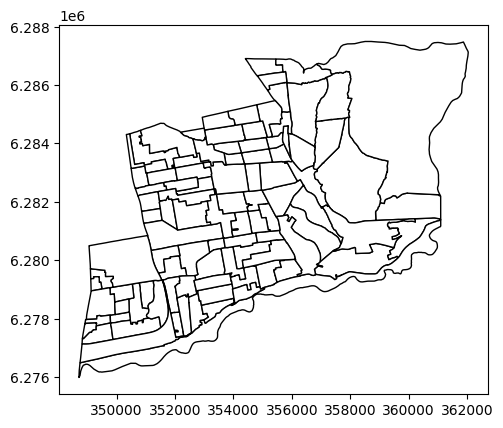

In [8]:
uv_puente = uv[(uv['NOMBRE_COM'] == 'PUENTE ALTO')]
uv_puente.plot(facecolor='white', edgecolor='black')
#uv_puente.head()

<Axes: >

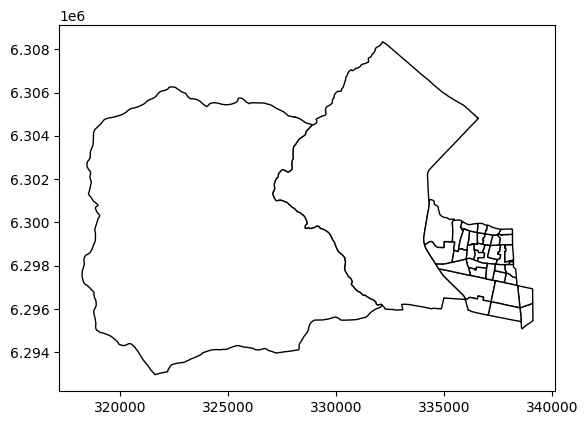

In [9]:
uv_concepcion = uv[(uv['NOMBRE_COM'] == 'PUDAHUEL')]
uv_concepcion.plot(facecolor='white', edgecolor='black')
#uv_concepcion.head()

La inersección de ambas coberturas la realizaremos con la función ‘overlay’, en cuyo argumento consideraremos el parámetro ‘how='intersection'’ con las coberturas que queremos intersectar. En este ejemplo, intersectaremos las áreas verdes de la comuna de Puente Alto con las unidades vecinales.

Lo importante en este geoprocesamiento, es la tabla de atributos resultantes, pues en ella se unieron ambas coberturas. Observe y analice la tabla de atributos resultante, la cual ahora tiene el área verde y la información de la unidad vecinal en la cual se ubican.

C:\Users\hcontreras\AppData\Local\Temp\ipykernel_9952\2958846293.py:1: UserWarning: `keep_geom_type=True` in overlay resulted in 15 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  areas_puente = gpd.overlay(areas, uv_puente, how='intersection')


<Axes: >

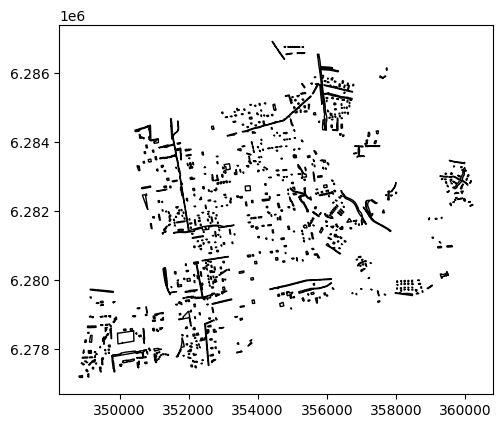

In [10]:
areas_puente = gpd.overlay(areas, uv_puente, how='intersection')
areas_puente.head()
areas_puente.plot(facecolor='white', edgecolor='black')

In [11]:
areas_puente.head()

,SUP_TOTAL_,NOMBRE_REG,CODIGO_REG,NOMBRE_COM,CUT,NOMBRE_UV,CODIGO_UV,PORC_VIV,COD_UNICO_,PERSONAS,...,FARMACIAS,SALUD_ALTA,SALUD_MEDI,SALUD_BAJA,SALUD_SIN_,SALUD_PRIV,SALUD_PUBL,SALUD_OTRO,TOTAL_SALU,geometry
0,3613.263047,METROPOLITANA DE SANTIAGO,13,PUENTE ALTO,13201,A68,A68,100.0000,13201_A68,5757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((354503.084 6286771.69, 354517.502 62..."
1,4461.274112,METROPOLITANA DE SANTIAGO,13,PUENTE ALTO,13201,A01,A01,97.3499,13201_A01,16770,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((350641.813 6284366.165, 350639.752 6..."
2,4461.274112,METROPOLITANA DE SANTIAGO,13,PUENTE ALTO,13201,B05,B05,93.9850,13201_B05,7006,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((350822.029 6284420.932, 350813.741 6..."
3,1708.132643,METROPOLITANA DE SANTIAGO,13,PUENTE ALTO,13201,A01,A01,97.3499,13201_A01,16770,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((350690.282 6283374.449, 350682.645 6..."
4,4734.558273,METROPOLITANA DE SANTIAGO,13,PUENTE ALTO,13201,A01,A01,97.3499,13201_A01,16770,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((350456.25 6284306.67, 350453.37 6284..."


<Axes: >

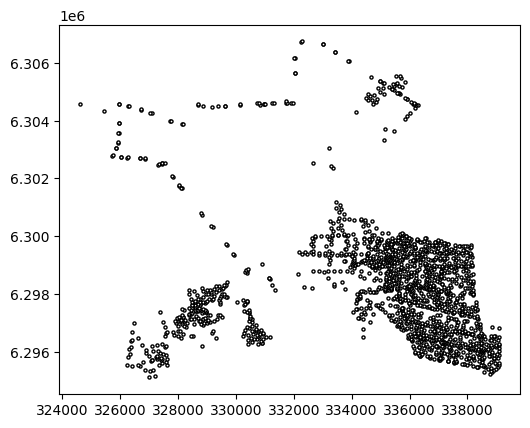

In [12]:
equip_concepcion = gpd.overlay(equipamiento, uv_concepcion, how='intersection')
equip_concepcion.head()
equip_concepcion.plot(facecolor='white', edgecolor='black', markersize=5)

In [13]:
equip_concepcion.head()

,TIPO_EQUIP,CALIDAD_U,PRESTADOR_,NOMBRE_REG,CODIGO_REG,NOMBRE_COM,CUT,NOMBRE_UV,CODIGO_UV,PORC_VIV,...,FARMACIAS,SALUD_ALTA,SALUD_MEDI,SALUD_BAJA,SALUD_SIN_,SALUD_PRIV,SALUD_PUBL,SALUD_OTRO,TOTAL_SALU,geometry
0,Grifo,Media,None,METROPOLITANA DE SANTIAGO,13,PUDAHUEL,13124,29,29,100.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (338791.91 6295248.16)
1,Paradero de transporte público,Media,None,METROPOLITANA DE SANTIAGO,13,PUDAHUEL,13124,29,29,100.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (338842.176 6295298.499)
2,Grifo,Media,None,METROPOLITANA DE SANTIAGO,13,PUDAHUEL,13124,35,35,100.0,...,3.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,POINT (327010 6295122)
3,Grifo,Media,None,METROPOLITANA DE SANTIAGO,13,PUDAHUEL,13124,29,29,100.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (338584.26 6295324.3)
4,Grifo,Media,None,METROPOLITANA DE SANTIAGO,13,PUDAHUEL,13124,29,29,100.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,POINT (338824.18 6295361.99)


Al igual que el caso anterior, la tabla de atributos resultante ahora contiene el equipamiento con la información de la unidad vecinal en la cual se ubican.

## 2. Funciones de distancia: Buffers

Este geoprocesamiento genera área cuyos puntos se encuentran a una distancia menor o igual a aquella que se especifique respecto a otro elemento. El resultado son polígonos que rodean a los objetos sobre los que se realiza este proceso.

En un primer ejemplo, crearemos buffers o áreas de incidencia alrededor de los cuarteles de Carabineros de la ciudad de Santiago a una distancia de 1.000 metros.

Si bien solo necesitamos la cobertura de los cuarteles para crear los corredores también consideraremos la de comunas para poder observarlos en su posición comunal.

Para este proceso ambas coberturas difieren en sus sistemas de referencia, por lo que se hace necesario igualarlos. Los cuarteles están en WGS 1984 y las comunas en SIRGAS 2000, ambas sin proyección. 

In [16]:
cuarteles  = gpd.read_file('shapes/cuartelesGS.shp')
santiago = gpd.read_file('shapes/ComunasGS.shp')

In [17]:
cuarteles.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
santiago.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [19]:
cuarteles = cuarteles.to_crs(32719)
santiago =santiago.to_crs(32719)

cuarteles.crs
santiago.crs

<Projected CRS: EPSG:32719>
Name: WGS 84 / UTM zone 19S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°W and 66°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Chile. Colombia. Peru.
- bounds: (-72.0, -80.0, -66.0, 0.0)
Coordinate Operation:
- name: UTM zone 19S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [24]:
cuarteles['TIPO_DE_UN'].value_counts()

TIPO_DE_UN
COMISARIA       48
SUBCOMISARIA    16
TENENCIA        12
RETEN            3
COMISARÍA        1
Name: count, dtype: int64

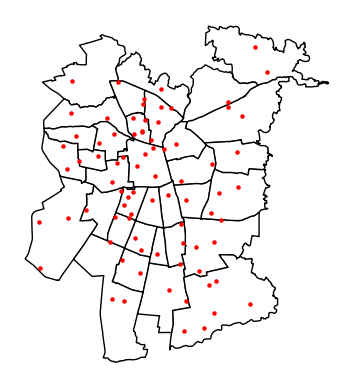

In [20]:
stgo = santiago.plot(facecolor='white', edgecolor='black')
ax = cuarteles.plot(ax=stgo, color='red', markersize=5)
ax.set_axis_off()

Los buffers los crearemos con la función ‘geometry.buffer’, en cuyo argumento consideraremos la distancia a la cual se desea crear.

In [25]:
cuarteles_buf = cuarteles.geometry.buffer(1000)

<Axes: >

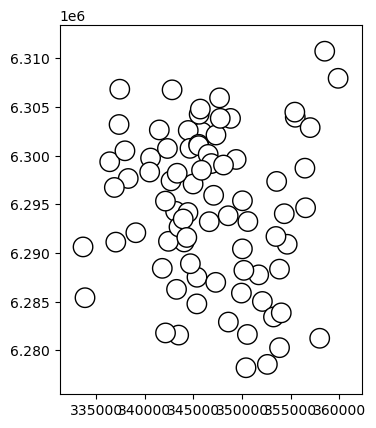

In [26]:
cuarteles_buf.plot(facecolor='white', edgecolor='black')

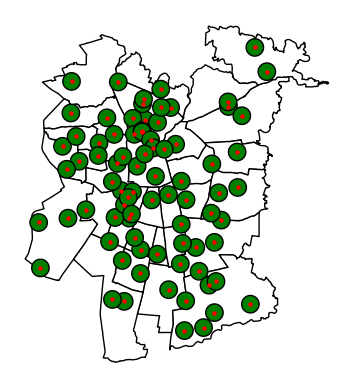

In [27]:
stgo = santiago.plot(facecolor='white', edgecolor='black')
ax = cuarteles_buf.plot(ax=stgo, facecolor='green', edgecolor='black')
ax = cuarteles.plot(ax=stgo, color='red', markersize=5)
ax.set_axis_off()

Como segundo ejemplo, crearemos buffers o áreas de incidencia alrededor de las líneas férreas de la región de O'Higgins a una distancia de 3.000 metros.

Si bien solo necesitamos la cobertura de las líneas férreas para crear los corredores también consideraremos la de comunas para poder observarlos en su posición comunal.

Para este proceso ambas coberturas no tienen un sistema de referencia, por lo que debemos creárselos (Averigüe cómo).

In [31]:
comunas06  = gpd.read_file('shapes/lim_admi_06.shp')
ferreas06 = gpd.read_file('shapes/ferreas06.shp')

In [36]:
comunas06.crs

In [56]:
ferreas06.crs

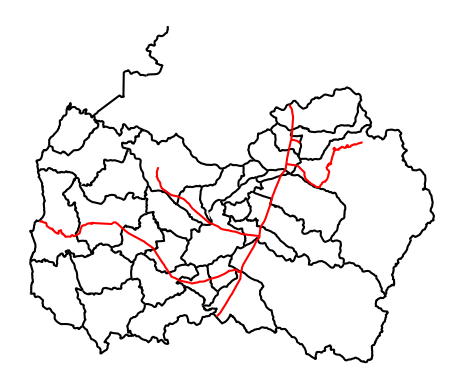

In [57]:
r06 = comunas06.plot(facecolor='white', edgecolor='black')
ax = ferreas06.plot(ax=r06, color='red')
ax.set_axis_off()

Creamos el buffer de 3.000 metros alrededor de las líneas férreas.

In [58]:
ferreas06_buf = ferreas06.geometry.buffer(3000)

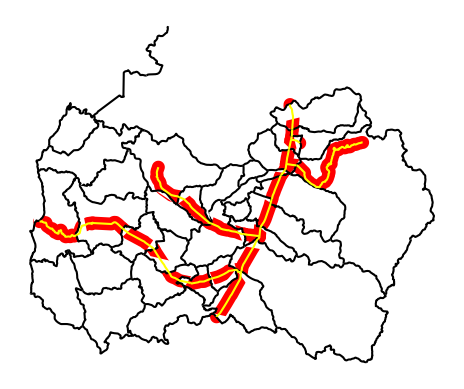

In [59]:
r06 = comunas06.plot(facecolor='white', edgecolor='black')
ax = ferreas06_buf.plot(ax=r06, facecolor='red')
ax = ferreas06.plot(ax=r06, color='yellow', markersize=5)
ax.set_axis_off()